# ***Ⅲ. 이미지 데이터 처리***
- 텍스트 데이터는 메모장 등으로 열면 바로 데이터가 보이지만 이미지는 내부적으로 어떤 값이 기록이 된 것일까요?
- 본 단원을 통해 이미지를 구성하는 요소를 알아보고 이를 이용해 이미지 데이터를 처리하고 분류하는 과정을 알아봅니다

## ***01. 이미지 데이터의 표현***
- 이미지 데이터의 구성요소에 대해 알아봅니다

## ***Opencv 설치***
- 프로그래밍 도구를 이용해 이미지 데이터를 다루기 위해서는 opencv-python 패키지라는 것을 설치하여 사용합니다
- Google colab에서는 기본적으로 설치되어 있습니다
- 만약 Google colab이 아니라 로컬 PC에서 사용한다면 아래 라이브러리를 설치합니다

In [ ]:
! pip3 install opencv-python

## ***Numpy 설치***
- 벡터와 행렬 연산을 도와주는 도구입니다
- 우리는 이미 이 도구를 사용해 보았습니다
- opencv-python이라는 도구는 numpy를 이용하기 때문에 opencv-python이 설치되어 있으면 numpy도 설치되어 있습니다

In [19]:
! pip3 install numpy

## ***행렬 표현하기***
- 교과서에 있는 행렬을 numpy를 이용해 표현해봅니다

In [23]:
import numpy as np

mat1 = np.array([[2, 3, 1],
                 [4, -2, 0]])

mat2 = np.array([[1],
                 [0],
                 [4]])

print(mat1)
print()
print(mat2)


[[ 2  3  1]
 [ 4 -2  0]]

[[1]
 [0]
 [4]]


## ***Numpy의 shape***

In [ ]:
print(mat1)
print()
print(mat1.shape) # 2행 3열

[[ 2  3  1]
 [ 4 -2  0]]

(2, 3)


In [28]:
print(mat2)
print()
print(mat2.shape) # 3행 1열

[[1]
 [0]
 [4]]

(3, 1)


## ***행렬의 차원 변경하기***
- Numpy에서 차원 변경은 전치행렬을 구하는 것이 아닙니다
- 사실 이 데이터는 연속된 데이터이고 연속공간 속에서의 데이터를 차원으로 끊는 것입니다
- 그래서 `[2, 3, 1, 4, -2, 0]` 의 연속된 데이터가 2x3 차원 또는 3x2 차원으로 각각 표현되는 것입니다

In [34]:
print(mat1)
print(mat1.shape) # 2행 3열
print()

mat1_new = mat1.reshape(3,2)
print(mat1_new)
print(mat1_new.shape) # 3행 2열
print()


[[ 2  3  1]
 [ 4 -2  0]]
(2, 3)

[[ 2  3]
 [ 1  4]
 [-2  0]]
(3, 2)



### ***연속 배열 선언 후 차원 바꾸기***

In [37]:
mat4 = np.array([[7, -2, 2, 5, 9, -6]]).reshape(3,2)
print(mat4)

[[ 7 -2]
 [ 2  5]
 [ 9 -6]]


## ***전치행렬 구하기***
- 행과 열을 바꿉니다

In [55]:
print(mat4.T)

[[ 7  2  9]
 [-2  5 -6]]


## ***행렬의 성분 가져오기***
- 아래와 같은 규칙이 있습니다
    - [행 성분, 열 성분] 으로 서술합니다
    - 행 성분의 인덱스는 0부터 시작합니다
    - 열 성분의 인덱스는 0부터 시작합니다



In [39]:
print(mat4)
print(mat4[1, 1])
print(mat4[2, 0])

[[ 7 -2]
 [ 2  5]
 [ 9 -6]]
5
9


## ***행렬 비교하기***
- 아래와 같이 행렬의 모든 성분이 동일한지 비교할 수 있습니다

In [46]:
x = 1
y = 1

mat1 = np.array([2, 3, 1, y]).reshape(2, 2)
print(mat1)
print()

mat2 = np.array([2, x, 1, 4]).reshape(2, 2)
print(mat2)
print()

bool((mat1 == mat2).all())

[[2 3]
 [1 1]]

[[2 1]
 [1 4]]



False

## ***흑백 이미지 행렬 구성하기***
- 교과서에 있는 가로8개, 세로8개로 구성된 흑백 이미지 행렬을 아래와 같이 구성해봅니다

In [9]:
import numpy as np

data = [
    "10001000",
    "11111000",
    "10101000",
    "01110001",
    "00100001",
    "01111001",
    "01111101",
    "10111110"
]

arr = np.array([[int(c) for c in row] for row in data]).astype(np.uint8)

arr

array([[1, 0, 0, 0, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 0, 0],
       [1, 0, 1, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 1],
       [0, 1, 1, 1, 1, 0, 0, 1],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [1, 0, 1, 1, 1, 1, 1, 0]], dtype=uint8)

## ***행렬을 이미지로 기록해보기***
- 위 행렬을 이미지로 기록하고 확인해봅니다

In [ ]:
import cv2

cv2.imwrite('gray.png', arr)

True

## ***이미지를 다시 행렬로 읽어보기***
- 이미지를 다시 행렬로 읽어봅니다
- 0과 1의 값이 그대로 있습니다
- 흑백 이미지라도 색상의 농도가 있습니다
- 색상의 농도는 0 ~ 255로 표현됩니다
  - 0에 가까울수록 어둡습니다
  - 따라서 0 ~ 255 스케일에서 0과 1의 농도는 거의 비슷하게 보입니다

In [11]:
import cv2


cv2.imread('gray.png', cv2.IMREAD_GRAYSCALE)

array([[1, 0, 0, 0, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 0, 0, 0],
       [1, 0, 1, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 1],
       [0, 1, 1, 1, 1, 0, 0, 1],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [1, 0, 1, 1, 1, 1, 1, 0]], dtype=uint8)

## ***색상 스케일 바꾸기***
- 0과 1이 아니라 0과 255로 바꿔봅니다

In [12]:
arr255 = arr * 255
arr255

array([[255,   0,   0,   0, 255,   0,   0,   0],
       [255, 255, 255, 255, 255,   0,   0,   0],
       [255,   0, 255,   0, 255,   0,   0,   0],
       [  0, 255, 255, 255,   0,   0,   0, 255],
       [  0,   0, 255,   0,   0,   0,   0, 255],
       [  0, 255, 255, 255, 255,   0,   0, 255],
       [  0, 255, 255, 255, 255, 255,   0, 255],
       [255,   0, 255, 255, 255, 255, 255,   0]], dtype=uint8)

In [13]:
import cv2


cv2.imwrite('gray255.png', arr255)

True

## ***색상 농도 바꾸기***
- 이번에는 255가 아니라 128로 바꿔보겠습니다

In [47]:
arr128 = arr * 128
arr128

array([[128,   0,   0,   0, 128,   0,   0,   0],
       [128, 128, 128, 128, 128,   0,   0,   0],
       [128,   0, 128,   0, 128,   0,   0,   0],
       [  0, 128, 128, 128,   0,   0,   0, 128],
       [  0,   0, 128,   0,   0,   0,   0, 128],
       [  0, 128, 128, 128, 128,   0,   0, 128],
       [  0, 128, 128, 128, 128, 128,   0, 128],
       [128,   0, 128, 128, 128, 128, 128,   0]], dtype=uint8)

- 이미지를 파일로 기록하고 확인해봅니다

In [48]:
import cv2

cv2.imwrite('gray128.png', arr128)

True

## ***컬러 이미지의 색상성분 이해하기***
- 아래와 같이 행렬을 만들고 파일로 기록해봅니다
- 그 파일을 다운로드 받고 속성 정보를 확인해보겠습니다

In [51]:
import cv2
import numpy as np

lst = \
[[[201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255]],

[[201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255]],

 [[201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255]],

 [[201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255],
  [201,174,255]]]

img_numpy = np.array(lst, dtype=np.uint8)
print(img_numpy)
cv2.imwrite('pink.png', img_numpy)

[[[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]]


True

## ***컬러 이미지를 파일로 읽어보기***
- 위에서 적은 숫자가 그대로 보이는 것을 확인할 수 있습니다
- 그러면 이미지 파일에는 각 픽셀별 색상정보가 숫자로 기록되어 있음을 알 수 있습니다

In [52]:
img_color = cv2.imread('pink.png')
print(img_color)

[[[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]

 [[201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]
  [201 174 255]]]


### ***Blue, Green, Red 이미지 읽어보기***
- 채널정보를 좀더 정확히 이해하기 위해 Blue only, Green only, Red only 이미지를 직접 만들고 읽어봅니다
- 먼저 모든 픽셀을 동일한 색으로 파일을 만들고 읽거봅니다
- 이후 각 색상별로 격자 격자무늬 파일을 만들고 읽어봅니다
- 3개의 원소 중에서 첫번째 원소에만 255라고 적혀있습니다
- 파란색 성분이 0 ~ 255 중에서 255만큼 진하게(최대로) 들어가 있다는 뜻입니다

In [ ]:
# 파란색 5x4 이미지 만들기
# 아래 픽셀값 중 아무거나 하나만 무작위로 바꿔서 실행해봅시다

import cv2
import numpy as np

lst = \
[[[255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0]],

[[255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0]],

 [[255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0]],

 [[255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0],
  [255, 0, 0]]]

img_numpy = np.array(lst, dtype=np.uint8)
cv2.imwrite('blue.png', img_numpy)

In [ ]:
# 초록색 5x4 이미지 만들기
# 아래 픽셀값 중 아무거나 하나만 무작위로 바꿔서 실행해봅시다

import cv2
import numpy as np

lst = \
[[[0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0]],

[[0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0]],

 [[0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0]],

 [[0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0],
  [0, 255, 0]]]

img_numpy = np.array(lst, dtype=np.uint8)
cv2.imwrite('green.png', img_numpy)

In [ ]:
# 붉은색 5x4 이미지 만들기
# 아래 픽셀값 중 아무거나 하나만 무작위로 바꿔서 실행해봅시다

import cv2
import numpy as np

lst = \
[[[0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255]],

[[0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255]],

 [[0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255]],

 [[0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255],
  [0, 0, 255]]]

img_numpy = np.array(lst, dtype=np.uint8)
cv2.imwrite('red.png', img_numpy)

### ***격자 형태 이미지 만들기***
- 아래 리스트의 구조와 실제 만들어진 이미지를 확인해봅시다
- 이미지의 가로, 세로 성분이 행렬로 어떻게 표현되는지 이해하기 위함입니다

In [68]:
import cv2
import numpy as np

lst = \
[[[255, 0, 0],
  [0, 0, 0],
  [255, 0, 0],
  [0, 0, 0],
  [255, 0, 0]],

[[0, 0, 0],
  [255, 0, 0],
  [0, 0, 0],
  [255, 0, 0],
  [0, 0, 0]],

 [[255, 0, 0],
  [0, 0, 0],
  [255, 0, 0],
  [0, 0, 0],
  [255, 0, 0]],

 [[0, 0, 0],
  [255, 0, 0],
  [0, 0, 0],
  [255, 0, 0],
  [0, 0, 0]]]

blue_grid = np.array(lst, dtype=np.uint8)
cv2.imwrite('blue_grid.png', blue_grid)

True

In [ ]:
import cv2

blue_img = cv2.imread('blue_grid.png')

print(blue_img)

## ***이미지를 코드창에서 확인하기***
- 픽셀이라는 것은 실제로 모니터상의 작은 하나의 화소입니다
- 이것을 우리가 눈으로 구분하기에 쉽지 않습니다
- 그래서 이를 큰 공간에 확대하여 보도록 합니다
- 유의하셔야 할 점은 픽셀 좌표와 아래 좌표가 다소 차이가 있다는 것입니다
- 픽셀 공간이 확대되어 그려지기 때문입니다
- (0, 0) 픽셀은 분명히 중심점이 (0, 0)에 위치해 있습니다
- 그러나 이를 중심으로 좌우상하로 확대되어 음수 좌표가 보이게 됩니다

In [ ]:
# imshow함수 준비
import cv2
from matplotlib import pyplot as plt

def cv2_imshow(img, title='Image', figsize=(5,5), axis='on'):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis(axis)
    plt.show()

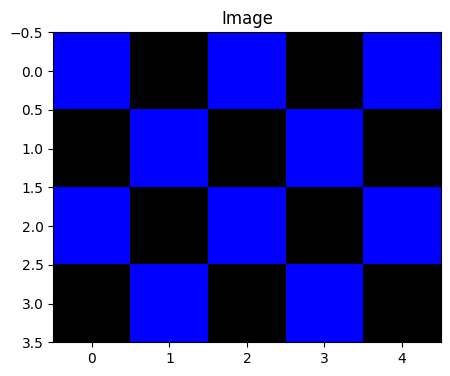

In [69]:
cv2_imshow(blue_grid)

### ***초록색 성분의 위치***
- 3개의 원소 중에서 두번째 원소에만 255라고 적혀있습니다
- 초록색 성분이 0 ~ 255 중에서 255만큼 진하게(최대로) 들어가 있다는 뜻입니다

In [72]:
import cv2
import numpy as np

lst = \
[[[0, 255, 0],
  [0, 0, 0],
  [0, 255, 0],
  [0, 0, 0],
  [0, 255, 0]],

[[0, 0, 0],
  [0, 255, 0],
  [0, 0, 0],
  [0, 255, 0],
  [0, 0, 0]],

 [[0, 255, 0],
  [0, 0, 0],
  [0, 255, 0],
  [0, 0, 0],
  [0, 255, 0]],

 [[0, 0, 0],
  [0, 255, 0],
  [0, 0, 0],
  [0, 255, 0],
  [0, 0, 0]]]

green_grid = np.array(lst, dtype=np.uint8)
cv2.imwrite('green_grid.png', green_grid)

True

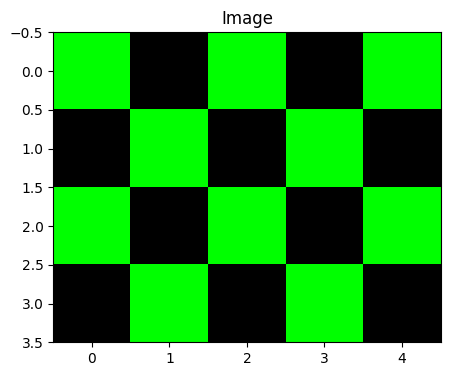

In [73]:
cv2_imshow(green_grid)

### ***빨간색 성분의 위치***
- 3개의 원소 중에서 오른쪽 원소에만 255라고 적혀있습니다
- 빨간색 성분이 0 ~ 255 중에서 255만큼 진하게(최대로) 들어가 있다는 뜻입니다

In [74]:
import cv2
import numpy as np

lst = \
[[[0, 0, 255],
  [0, 0, 0],
  [0, 0, 255],
  [0, 0, 0],
  [0, 0, 255]],

[[0, 0, 0],
  [0, 0, 255],
  [0, 0, 0],
  [0, 0, 255],
  [0, 0, 0]],

 [[0, 0, 255],
  [0, 0, 0],
  [0, 0, 255],
  [0, 0, 0],
  [0, 0, 255]],

 [[0, 0, 0],
  [0, 0, 255],
  [0, 0, 0],
  [0, 0, 255],
  [0, 0, 0]]]

red_grid = np.array(lst, dtype=np.uint8)
cv2.imwrite('red_grid.png', red_grid)

True

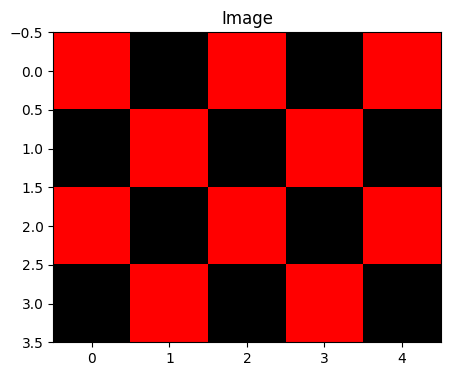

In [75]:
cv2_imshow(red_grid)

## ***원하는 색의 이미지 출력하기***

In [53]:
import cv2
import numpy as np

blue = 146
green = 199
red = 237

lst = \
[[[blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red]],

[[blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red]],

 [[blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red]],

 [[blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red],
  [blue,green,red]]]

img_numpy = np.array(lst, dtype=np.uint8)
print(img_numpy)
cv2.imwrite('custom_color.png', img_numpy)

[[[146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]]

 [[146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]]

 [[146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]]

 [[146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]
  [146 199 237]]]


True

## ***텍스트 파일에 색상정보 기록하고 읽기***
- 숫자 하나씩 쓰고 개행이 나오는 포맷입니다
- 맨처음 3행은 높이, 너비, 채널 수 입니다
- 그 밑으로는 왼쪽 위부터 오른쪽 아래로 내려가면서 나오는 픽셀별 채널 색상 정보입니다

In [57]:
import cv2

myimage = cv2.imread('pink.png')

height, width, channel = myimage.shape

f = open('myimage.txt', 'w')
f.write(str(height))
f.write('\n')
f.write(str(width))
f.write('\n')
f.write(str(channel))
f.write('\n')

for h in range(0, height):
    for w in range(0, width):
        for c in range(0, channel):
            f.write(str(myimage[h][w][c]))
            f.write('\n')

f.close()


### ***우리들만의 이미지 내용을 텍스트로 출력해봅시다***
- 그냥 텍스트파일 입니다
- 한줄에 숫자 하나씩 써있는 텍스트 파일 입니다

In [58]:
with open('myimage.txt', 'r') as fp:
    for line in fp.readlines():
        print(line.rstrip())

4
5
3
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255
201
174
255


### ***우리만의 이미지 포맷을 읽어봅시다***
- 똑같이 읽어지는지 확인해봅니다
- 그저 숫자가 써있는 텍스트파일이었는데 이미지였습니다
- 따라서 이미지는 그저 숫자가 써있는 정보 라는 것을 알 수 있습니다
- 1주라 강의 영상-3 에서는 마지막 줄의 myimg.astype(np.uint8) 이 누락되어 있습니다
- 각 픽셀 색상값은 0 ~ 255의 값을 갖기 때문에 uint8 타입으로 변환해주어야 합니다

In [61]:
import numpy as np

f = open('myimage.txt', 'r')

height = int(f.readline().strip())
width  = int(f.readline().strip())
channel  = int(f.readline().strip())

myimg = np.arange(height*width*channel)
myimg = myimg.reshape(height, width, channel).astype(np.uint8)

for h in range(0, height):
    for w in range(0, width):
        for c in range(0, channel):
            value = int(f.readline().strip())
            myimg[h][w][c] = value
            print(f'행렬 성분 [{h}][{w}][{c}]에 {value}를 채웁니다')

행렬 성분 [0][0][0]에 201를 채웁니다
행렬 성분 [0][0][1]에 174를 채웁니다
행렬 성분 [0][0][2]에 255를 채웁니다
행렬 성분 [0][1][0]에 201를 채웁니다
행렬 성분 [0][1][1]에 174를 채웁니다
행렬 성분 [0][1][2]에 255를 채웁니다
행렬 성분 [0][2][0]에 201를 채웁니다
행렬 성분 [0][2][1]에 174를 채웁니다
행렬 성분 [0][2][2]에 255를 채웁니다
행렬 성분 [0][3][0]에 201를 채웁니다
행렬 성분 [0][3][1]에 174를 채웁니다
행렬 성분 [0][3][2]에 255를 채웁니다
행렬 성분 [0][4][0]에 201를 채웁니다
행렬 성분 [0][4][1]에 174를 채웁니다
행렬 성분 [0][4][2]에 255를 채웁니다
행렬 성분 [1][0][0]에 201를 채웁니다
행렬 성분 [1][0][1]에 174를 채웁니다
행렬 성분 [1][0][2]에 255를 채웁니다
행렬 성분 [1][1][0]에 201를 채웁니다
행렬 성분 [1][1][1]에 174를 채웁니다
행렬 성분 [1][1][2]에 255를 채웁니다
행렬 성분 [1][2][0]에 201를 채웁니다
행렬 성분 [1][2][1]에 174를 채웁니다
행렬 성분 [1][2][2]에 255를 채웁니다
행렬 성분 [1][3][0]에 201를 채웁니다
행렬 성분 [1][3][1]에 174를 채웁니다
행렬 성분 [1][3][2]에 255를 채웁니다
행렬 성분 [1][4][0]에 201를 채웁니다
행렬 성분 [1][4][1]에 174를 채웁니다
행렬 성분 [1][4][2]에 255를 채웁니다
행렬 성분 [2][0][0]에 201를 채웁니다
행렬 성분 [2][0][1]에 174를 채웁니다
행렬 성분 [2][0][2]에 255를 채웁니다
행렬 성분 [2][1][0]에 201를 채웁니다
행렬 성분 [2][1][1]에 174를 채웁니다
행렬 성분 [2][1][2]에 255를 채웁니다
행렬 성분 [2][2][0]에 201를 채웁니다
행

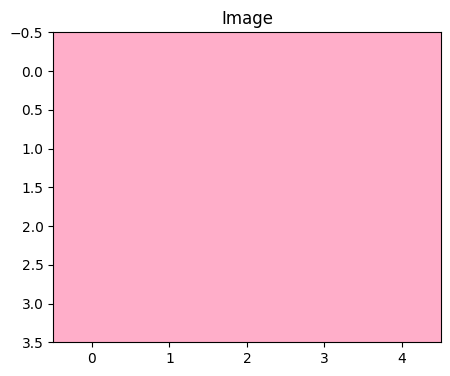

In [64]:
cv2_imshow(myimg)